In [1]:
import re
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ==========================================
# 0) 재현성 고정
# ==========================================
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_seeds(42)

# =========================
# 1) 설정 (기존 유지)
# =========================
BASE_PATH = Path("/content/drive/MyDrive/RichardFel/RichardFel-VAE-8073887/Raw_data")
FOLDERS = {
    "Healthy": BASE_PATH / "Data_Healthy",
    "Long": BASE_PATH / "Data_long",
    "Stroke": BASE_PATH / "Data_Stroke",
}
SENSORS = ["leftfoot", "rightfoot", "lowback"] # 순서 고정을 위해 리스트로 변경
FEATURES = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
WINDOW_SIZE = 128
STEP_SIZE = 64

# [기존 파싱 함수들 및 build_session_index 유지 - 생략 없이 그대로 사용]
def extract_base_id(subj: str) -> str:
    m = re.match(r"^(S\d+|H\d+)", str(subj))
    return m.group(1) if m else str(subj)

def extract_protocol(parts_lower: list[str]) -> str:
    if "longitudinal" in parts_lower: return "Longitudinal"
    if "testretest" in parts_lower: return "TestRetest"
    return "Unknown"

def parse_filename(path: Path):
    stem = path.stem
    parts = stem.split("_")
    if len(parts) < 4: return None
    sensor = parts[-1].lower()
    if sensor not in SENSORS: return None
    subj_raw = parts[0]
    group = parts[1] if len(parts) > 1 else "Unknown"
    parts_lower = [p.lower() for p in parts]
    protocol = extract_protocol(parts_lower)
    t, aid = parts[-3], parts[-2]
    if protocol in ["Longitudinal", "TestRetest"]:
        i = parts_lower.index(protocol.lower())
        if i + 2 < len(parts) - 1: t, aid = parts[i + 1], parts[i + 2]
    session_id = "_".join(parts[:-1])
    return {
        "session_id": session_id, "Subj": subj_raw, "BaseID": extract_base_id(subj_raw),
        "Group": group, "Protocol": protocol, "T": t, "Aid": aid,
        "Sensor": sensor, "Path": path,
    }

def build_session_index():
    rows = []
    total_csv_found = 0
    parsed_success = 0

    for label, folder in FOLDERS.items():
        if not folder.exists():
            print(f"[경고] 폴더 경로를 찾을 수 없습니다: {folder}")
            continue

        for p in folder.glob("**/*.csv"):
            total_csv_found += 1
            meta = parse_filename(p)
            if meta:
                meta["LabelFolder"] = label
                rows.append(meta)
                parsed_success += 1

    print(f"1. 발견된 전체 CSV 파일 수: {total_csv_found}")
    print(f"2. 파일명 파싱 성공 수: {parsed_success}")

    idx = pd.DataFrame(rows)
    if idx.empty:
        print("[실패] 파싱된 데이터가 없어 파이프라인이 중단되었습니다.")
        return pd.DataFrame()

    counts = idx.groupby("session_id")["Sensor"].nunique()
    valid_ids = counts[counts == 3].index
    print(f"3. 3개 센서가 모두 존재하는 온전한 세션 수: {len(valid_ids)}")

    idx = idx[idx["session_id"].isin(valid_ids)].copy()
    if idx.empty:
        print("[실패] 3개 센서가 짝지어진 세션이 하나도 없습니다.")
        return pd.DataFrame()

    wide = idx.pivot_table(
        index=["session_id", "Subj", "BaseID", "Group", "Protocol", "T", "Aid", "LabelFolder"],
        columns="Sensor", values="Path", aggfunc="first"
    ).reset_index()
    wide.columns.name = None
    return wide

# =========================
# 2) 로드 및 가공 (수정됨)
# =========================
def load_and_interpolate_single(filepath):
    df = pd.read_csv(filepath)
    if "Unnamed: 0" in df.columns: df.drop(columns=["Unnamed: 0"], inplace=True)
    for col in FEATURES:
        if col not in df.columns: df[col] = 0.0
    df[FEATURES] = df[FEATURES].apply(pd.to_numeric, errors="coerce").interpolate(limit_direction="both")
    return df[FEATURES].fillna(0).values

def load_session_data(row):
    """3개 센서 데이터를 로드하여 병합 (N x 18 차원 생성)"""
    sensor_data_list = []
    min_length = float('inf')

    # 3개 센서 데이터 로드 및 최소 길이 파악 (동기화 보정)
    for sensor in SENSORS:
        data = load_and_interpolate_single(row[sensor])
        sensor_data_list.append(data)
        min_length = min(min_length, len(data))

    # 최소 길이에 맞춰 자르고 (Truncate) 가로로 병합 (Concatenate)
    truncated_data = [data[:min_length, :] for data in sensor_data_list]
    merged_data = np.hstack(truncated_data) # 최종 형태: (min_length, 18)
    return merged_data

def pad_and_extract_windows(scaled_data):
    """짧은 데이터 패딩 및 윈도우 추출"""
    length = len(scaled_data)
    # 데이터가 윈도우 사이즈보다 작으면 0으로 패딩
    if length < WINDOW_SIZE:
        pad_width = ((0, WINDOW_SIZE - length), (0, 0))
        scaled_data = np.pad(scaled_data, pad_width, mode='constant', constant_values=0)
        length = len(scaled_data)

    windows = []
    for i in range(0, length - WINDOW_SIZE + 1, STEP_SIZE):
        windows.append(scaled_data[i : i + WINDOW_SIZE])
    return windows

# ==========================================
# 3) 파이프라인 실행 (구조적 결함 해결)
# ==========================================
def run_ae_pipeline():
    idx = build_session_index() # 이전에 드린 디버깅용 함수를 그대로 쓰셔도 무방합니다.
    print(f"Total complete sessions: {len(idx)}")

    # 그룹별 데이터 분리
    idx_healthy = idx[idx["LabelFolder"] == "Healthy"]
    idx_stroke = idx[idx["LabelFolder"] == "Stroke"]
    idx_long = idx[idx["LabelFolder"] == "Long"]

    # 1. 피험자(Subject) 단위 독립 분할 (데이터 누수 차단 및 단일 세션 에러 해결)
    unique_healthy_subjects = idx_healthy["Subj"].unique()

    # 피험자 목록을 8:2로 분할
    train_subj, test_subj = train_test_split(
        unique_healthy_subjects, test_size=0.2, random_state=42
    )

    # 분할된 피험자를 기준으로 해당 피험자의 모든 세션을 할당
    idx_train_h = idx_healthy[idx_healthy["Subj"].isin(train_subj)]
    idx_test_h = idx_healthy[idx_healthy["Subj"].isin(test_subj)]

    print(f"Healthy Train Subjects: {len(train_subj)}명, Sessions: {len(idx_train_h)}")
    print(f"Healthy Test Subjects: {len(test_subj)}명, Sessions: {len(idx_test_h)}")


    # 2. Train 데이터(Healthy)로만 Scaler 학습 (스케일러 누수 방지)
    print("Fitting StandardScaler strictly on Train Healthy group...")
    all_train_data = []
    for _, row in idx_train_h.iterrows():
        try:
            data = load_session_data(row)
            all_train_data.append(data)
        except: continue
    concat_train_data = np.vstack(all_train_data)

    scaler = StandardScaler()
    scaler.fit(concat_train_data) # (N, 18) 형태에 대해 fit

    # 3. 윈도우 추출 함수 (그룹별 처리)
    def process_group(idx_group, group_name):
        X, meta = [], []
        for _, row in idx_group.iterrows():
            try:
                merged_data = load_session_data(row)
                scaled_data = scaler.transform(merged_data)
                windows = pad_and_extract_windows(scaled_data)

                for w in windows:
                    info = {'session_id': row['session_id'], 'group': group_name, 'time': row['T']}
                    X.append(w)
                    meta.append(info)
            except: continue
        return np.array(X), pd.DataFrame(meta)

    print("Extracting windows and applying spatial fusion...")
    X_train_h, meta_train_h = process_group(idx_train_h, "Healthy_Train")
    X_test_h, meta_test_h = process_group(idx_test_h, "Healthy_Test")
    X_stroke, stroke_meta = process_group(idx_stroke, "Stroke")
    X_long, long_meta = process_group(idx_long, "Long")

    print("\n=== Corrected Data Pipeline Results ===")
    print(f"1. X_train_h (Healthy 학습용): {X_train_h.shape} -> (Samples, 128, 18)")
    print(f"2. X_test_h  (Healthy 검증용): {X_test_h.shape}")
    print(f"3. X_stroke  (환자 분석용)   : {X_stroke.shape}")
    print(f"4. X_long    (종단 추적용)   : {X_long.shape}")

    return (X_train_h, X_test_h, X_stroke, X_long,
            meta_train_h, meta_test_h, stroke_meta, long_meta, scaler)

# 데이터 준비 완료
(X_train_h, X_test_h, X_stroke, X_long,
 train_h_meta, test_h_meta, stroke_meta, long_meta, scaler) = run_ae_pipeline()

1. 발견된 전체 CSV 파일 수: 1148
2. 파일명 파싱 성공 수: 1142
3. 3개 센서가 모두 존재하는 온전한 세션 수: 379
Total complete sessions: 379
Healthy Train Subjects: 27명, Sessions: 45
Healthy Test Subjects: 7명, Sessions: 14
Fitting StandardScaler strictly on Train Healthy group...
Extracting windows and applying spatial fusion...

=== Corrected Data Pipeline Results ===
1. X_train_h (Healthy 학습용): (9061, 128, 18) -> (Samples, 128, 18)
2. X_test_h  (Healthy 검증용): (2816, 128, 18)
3. X_stroke  (환자 분석용)   : (13945, 128, 18)
4. X_long    (종단 추적용)   : (54530, 128, 18)


In [2]:
import numpy as np
import pandas as pd

# ==========================================
# [데이터 통합] X_all_raw, y_all, meta_all 생성
# ==========================================
print("--- 데이터 통합 시작 (Healthy + Stroke) ---")

# 1. Raw 데이터 통합 (정상군 학습/검증 + 환자군)
# X_train_h, X_test_h, X_stroke가 메모리에 있어야 합니다.
X_all_raw = np.concatenate([X_train_h, X_test_h, X_stroke], axis=0)

# 2. 라벨 생성 (정상은 0, 환자는 1)
y_healthy = np.zeros(len(X_train_h) + len(X_test_h))
y_stroke = np.ones(len(X_stroke))
y_all = np.concatenate([y_healthy, y_stroke], axis=0)

# 3. 메타데이터 통합 (피험자 ID 추적용)
# train_h_meta, test_h_meta, stroke_meta가 메모리에 있어야 합니다.
meta_all = pd.concat([train_h_meta, test_h_meta, stroke_meta], ignore_index=True)

# 4. BaseID 유효성 확인 (session_id에서 추출)
import re
def extract_base_id(sid):
    m = re.match(r"^(S\d+|H\d+)", str(sid))
    return m.group(1) if m else str(sid)

if 'BaseID' not in meta_all.columns:
    meta_all['BaseID'] = meta_all['session_id'].apply(extract_base_id)

print(f"✅ 통합 완료!")
print(f"총 샘플 수: {len(X_all_raw)}")
print(f"피험자 수: {meta_all['BaseID'].nunique()}명")
print(f"라벨 분포: 정상({np.sum(y_all==0)}), 환자({np.sum(y_all==1)})")

--- 데이터 통합 시작 (Healthy + Stroke) ---
✅ 통합 완료!
총 샘플 수: 25822
피험자 수: 54명
라벨 분포: 정상(11877), 환자(13945)


In [3]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import GroupKFold
from sklearn.utils import class_weight
from sklearn.model_selection import GroupKFold
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, recall_score, classification_report
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import GroupKFold
from keras.callbacks import EarlyStopping

# ==========================================
# [공학적 개선] 통합 분류 모델 정의 (Reinforced Encoder)
# ==========================================
def build_reinforced_model(input_shape=(128, 18), reg_factor=0.01):
    inputs = Input(shape=input_shape)

    # 1. 인코더 파트 (AE 구조 계승 및 강화)
    x = Conv1D(32, kernel_size=5, activation='relu', padding='same', kernel_regularizer=l2(reg_factor))(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(64, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(reg_factor))(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(reg_factor))(x)
    x = BatchNormalization()(x)
    # 인코더의 최종 출력 (128 Features)

    # 2. 분류기 파트 (통합)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.5)(x)
    x = Dense(32, activation='relu', kernel_regularizer=l2(reg_factor))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

# ==========================================
# [실행] Group 5-Fold 통합 학습
# ==========================================
# 원본 데이터(X_train_h_raw, X_stroke_raw 등)를 직접 사용해야 합니다.
# 여기서는 통합된 X_all_raw, y_all, meta_all이 준비되었다고 가정합니다.

gkf = GroupKFold(n_splits=5)
final_fold_results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_all_raw, y_all, groups=meta_all['BaseID'])):
    print(f"\n>> Fold {fold+1} 통합 학습 시작...")

    X_train_f, X_test_f = X_all_raw[train_idx], X_all_raw[test_idx]
    y_train_f, y_test_f = y_all[train_idx], y_all[test_idx]

    tf.keras.backend.clear_session()
    model = build_reinforced_model()
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003), # 정교한 조정을 위해 하향
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

    # 클래스 가중치 계산
    weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_f), y=y_train_f)
    cw_dict = {i: weights[i] for i in range(len(weights))}

    # 학습
    model.fit(X_train_f, y_train_f, epochs=50, batch_size=128,
              validation_data=(X_test_f, y_test_f), class_weight=cw_dict,
              callbacks=[EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)],
              verbose=0)

    # 평가
    y_prob = model.predict(X_test_f, verbose=0)
    y_pred = (y_prob > 0.5).astype(int)
    b_acc = balanced_accuracy_score(y_test_f, y_pred)
    final_fold_results.append(b_acc)
    print(f"Fold {fold+1} Balanced Acc: {b_acc:.4f}")

print(f"\n통합 학습 평균 Balanced Acc: {np.mean(final_fold_results):.4f}")


>> Fold 1 통합 학습 시작...
Fold 1 Balanced Acc: 0.8475

>> Fold 2 통합 학습 시작...
Fold 2 Balanced Acc: 0.7693

>> Fold 3 통합 학습 시작...
Fold 3 Balanced Acc: 0.9645

>> Fold 4 통합 학습 시작...
Fold 4 Balanced Acc: 0.9453

>> Fold 5 통합 학습 시작...
Fold 5 Balanced Acc: 0.9736

통합 학습 평균 Balanced Acc: 0.9000


<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1497/3487078506.py:19: SyntaxWarning: invalid escape sequence '\d'
  long_meta['time_num'] = pd.to_numeric(long_meta['time'].str.extract('(\d+)')[0], errors='coerce').fillna(0)



--- 5. 종단 데이터(X_long) 실전 추론 시작 ---
214/214 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step

[실전 테스트 결과]
총 샘플 수: 54530
환자(Stroke)로 분류된 샘플: 43257 (79.33%)

--- 시간(T)별 환자 확률(Stroke Probability) 추이 ---
   time_num      mean       std  count
0         0  0.744447  0.380944  13834
1         1  0.848826  0.306948   8880
2         2  0.777706  0.359765  11845
3         3  0.768122  0.381194   9730
4         4  0.790111  0.357767   4492
5         5  0.782498  0.357270   2777
6         6  0.887654  0.247967   1482
7         7  0.846776  0.300816   1283
8         8  0.757913  0.356055    207


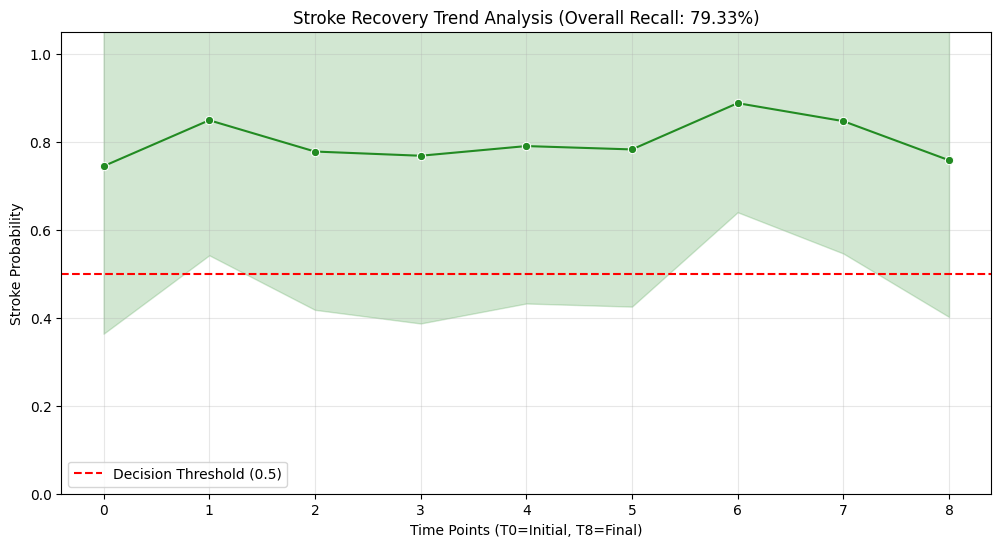

In [4]:
# ==========================================
# 5. 종단 데이터(X_long) 최종 블라인드 테스트 (5-Fold 모델 버전)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- 5. 종단 데이터(X_long) 실전 추론 시작 ---")

# 1) 예측 수행 (현재 메모리의 model 변수 사용)
y_long_prob = model.predict(X_long, batch_size=256, verbose=1)

y_long_pred = (y_long_prob > 0.5).astype(int)

# 2) 결과 집계 및 meta 데이터 업데이트
long_meta['Pred_Stroke_Prob'] = y_long_prob.flatten()
long_meta['Pred_Label'] = y_long_pred.flatten()

# T0, T1 등의 문자열에서 숫자만 추출하여 정렬용 컬럼 생성
long_meta['time_num'] = pd.to_numeric(long_meta['time'].str.extract('(\d+)')[0], errors='coerce').fillna(0)

total_long = len(X_long)
stroke_detected = np.sum(y_long_pred)
detection_rate = (stroke_detected / total_long) * 100

print(f"\n[실전 테스트 결과]")
print(f"총 샘플 수: {total_long}")
print(f"환자(Stroke)로 분류된 샘플: {stroke_detected} ({detection_rate:.2f}%)")

# 3) 시간대별(T0 ~ T8) 통계 계산
long_summary = long_meta.groupby('time_num')['Pred_Stroke_Prob'].agg(['mean', 'std', 'count']).reset_index()
print("\n--- 시간(T)별 환자 확률(Stroke Probability) 추이 ---")
print(long_summary)

# 4) 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=long_meta, x='time_num', y='Pred_Stroke_Prob', marker='o', errorbar='sd', color='forestgreen')
plt.axhline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.title(f'Stroke Recovery Trend Analysis (Overall Recall: {detection_rate:.2f}%)')
plt.ylabel('Stroke Probability')
plt.xlabel('Time Points (T0=Initial, T8=Final)')
plt.xticks(range(int(long_meta['time_num'].max()) + 1))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
import joblib
import os

# 저장할 디렉토리 생성
save_dir = "C:/Users/hanse/OneDrive/바탕 화면/연구"
os.makedirs(save_dir, exist_ok=True)

# 1) 전체 분류 모델 저장 (최종 Fold 모델 등)
model.save(os.path.join(save_dir, "stroke_classifier_v1.keras"))

# 2) 인코더 모델 별도 저장 (특징 추출용으로 상시 활용 가능)
# 첫 번째 모델(model)이 이미 학습되었다고 가정합니다.
# 모델의 레이어 이름을 확인하여 'GlobalAveragePooling1D' 앞까지를 인코더로 묶습니다.

# 인코더 부분만 따로 떼어내기 (입력부터 GAP 층 전까지)
# 보통 7번째 레이어 근처가 인코더의 끝입니다.
encoder_model = tf.keras.Model(inputs=model.input,
                               outputs=model.layers[-5].output) # -5는 예시이며, 실제 GAP 층 앞 번호를 확인해야 합니다.

print("✅ 첫 번째 모델에서 인코더 모델 분리 완료")
encoder_model.save(os.path.join(save_dir, "walking_encoder_v1.keras"))

# 3) 스케일러 저장 (매우 중요: 학습 시의 평균/표준편차 보존)
joblib.dump(scaler, os.path.join(save_dir, "walking_scaler.gz"))

print(f"✅ 모든 모델과 스케일러가 {save_dir}에 저장되었습니다.")

✅ 첫 번째 모델에서 인코더 모델 분리 완료
✅ 모든 모델과 스케일러가 C:/Users/hanse/OneDrive/바탕 화면/연구에 저장되었습니다.


BaseID 확인: ['S1085' 'S1294' 'S1599' 'S1676' 'S1707']


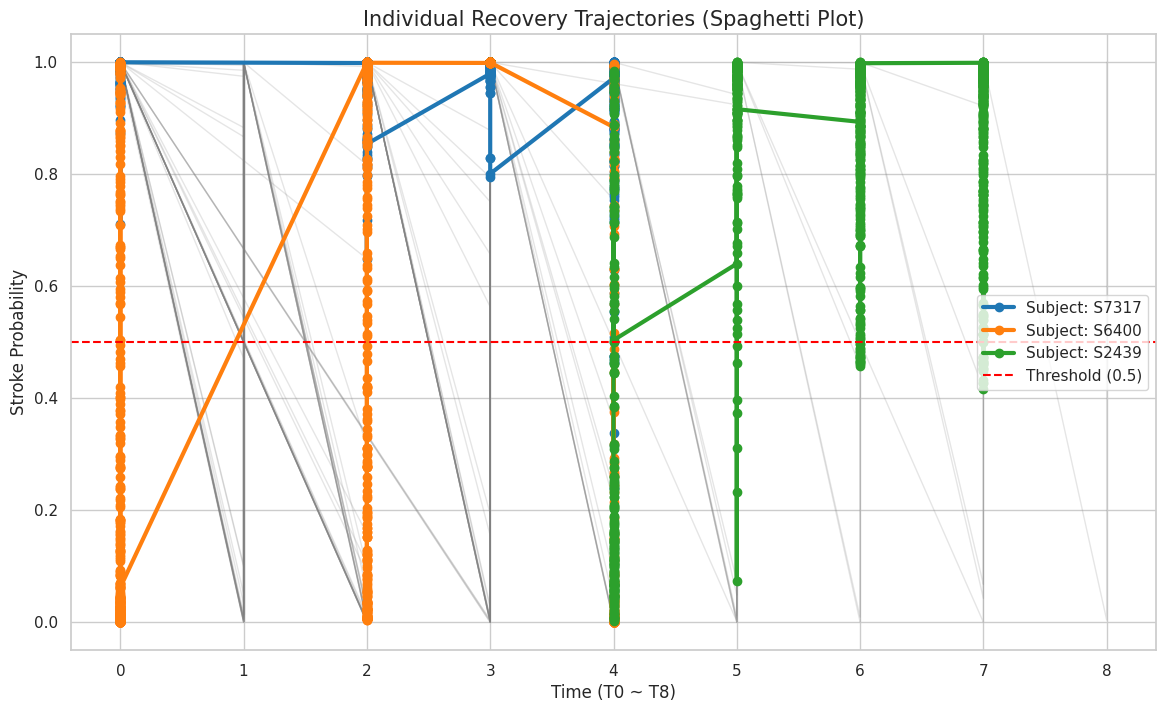

--- 6-2. 시간별 확률 분포 변화 시각화 ---


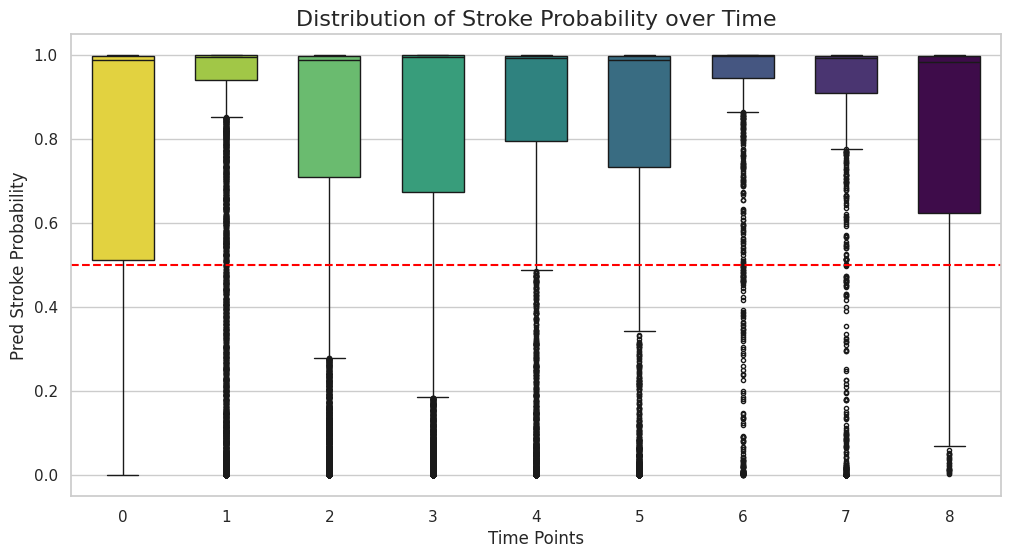

--- 6-3. 최적 모델의 Confusion Matrix 시각화 ---


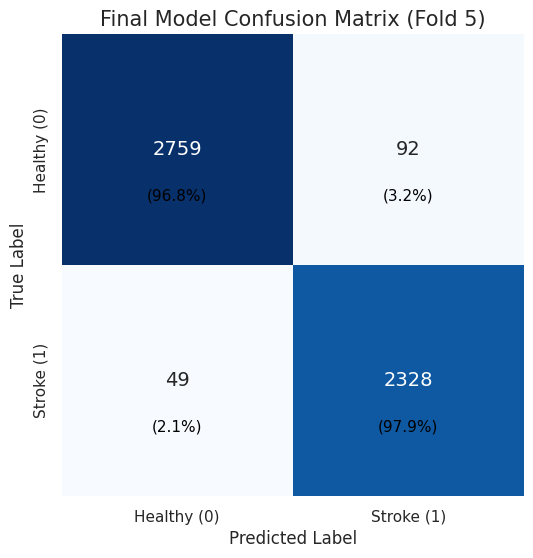

--- 6-4. 5-Fold ROC Curves 시각화 ---


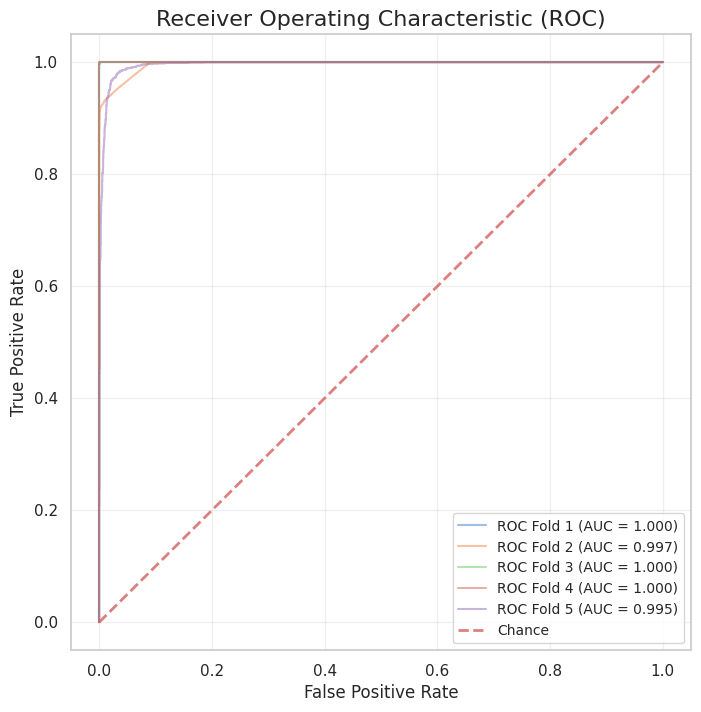


=== 추가 시각화 완료 ===


In [6]:
# 1) long_meta에 BaseID가 있는지 확인하고 없으면 생성합니다.
if 'BaseID' not in long_meta.columns:
    # session_id에서 S01, H02 같은 ID를 추출하여 BaseID 컬럼 생성
    long_meta['BaseID'] = long_meta['session_id'].apply(extract_base_id)

# 2) 시각화 코드 재실행 (Spaghetti Plot 부분)
print(f"BaseID 확인: {long_meta['BaseID'].unique()[:5]}") # 데이터가 잘 들어갔는지 확인

# ==========================================
# 6. 추가 심층 시각화 분석
# ==========================================
import matplotlib.patches as mpatches

# 그래프 스타일 설정 (Seaborn default)
sns.set_theme(style="whitegrid", palette="muted")

# 6-1. 개별 피험자별 종단 추적 (Spaghetti Plot) 수정본
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

# 배경: 모든 피험자의 흐름 (BaseID 기준)
sns.lineplot(
    data=long_meta,
    x='time_num',
    y='Pred_Stroke_Prob',
    units='BaseID',    # 이제 BaseID가 존재하므로 에러가 나지 않습니다.
    estimator=None,
    color='gray',
    alpha=0.2,
    linewidth=1
)

# 강조: 데이터 포인트가 가장 많은 상위 피험자 시각화
top_subjects = long_meta['BaseID'].value_counts().nlargest(3).index
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, subj in enumerate(top_subjects):
    subj_data = long_meta[long_meta['BaseID'] == subj].sort_values('time_num')
    plt.plot(subj_data['time_num'], subj_data['Pred_Stroke_Prob'],
             marker='o', linewidth=3, label=f'Subject: {subj}', color=colors[i])

plt.axhline(0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.title('Individual Recovery Trajectories (Spaghetti Plot)', fontsize=15)
plt.xlabel('Time (T0 ~ T8)', fontsize=12)
plt.ylabel('Stroke Probability', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()


# 6-2. 시간별 분류 결과 분포 (Ridge Plot 느낌의 Boxplot)
# ---------------------------------------------------
# 목적: 시간이 지남에 따라 모델의 확신도(Probability Distribution)가 어떻게 변하는지 파악.
print("--- 6-2. 시간별 확률 분포 변화 시각화 ---")

plt.figure(figsize=(12, 6))

# Boxplot으로 분포와 이상치 시각화
sns.boxplot(
    data=long_meta,
    x='time_num',
    y='Pred_Stroke_Prob',
    hue='time_num', # 시간별 색상 지정
    palette='viridis_r', # 시간에 따라 변하는 색상
    legend=False,
    width=0.6,
    fliersize=3 # 이상치 크기 조절
)

# Swarmplot으로 개별 데이터 포인트 오버레이 (데이터가 아주 많지 않을 때 유용)
if len(long_meta) < 1000: # 데이터 포인트가 너무 많으면 중복되어 보기 나쁨
    sns.swarmplot(
        data=long_meta,
        x='time_num',
        y='Pred_Stroke_Prob',
        color=".25",
        size=3,
        alpha=0.5
    )

plt.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Threshold')
plt.title('Distribution of Stroke Probability over Time', fontsize=16)
plt.ylabel('Pred Stroke Probability', fontsize=12)
plt.xlabel('Time Points', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.show()


# 6-3. 혼동 행렬 (Confusion Matrix) - 최적 모델 기준 (마지막 Fold)
# -------------------------------------------------------------
# 목적: 모델의 구체적인 오류 유형(FP vs FN) 분석. (통합 데이터에 대한 홀드아웃 세트 사용)
print("--- 6-3. 최적 모델의 Confusion Matrix 시각화 ---")
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(7, 6))

# 마지막 Fold의 검증 데이터(test_idx)와 예측값(y_pred)을 사용
# gkf.split 순회 내부에 있어야 정확하지만, 편의상 마지막 모델 기준으로 계산
# 더 정확한 분석을 위해서는 Fold 순회 내에 이 코드를 넣고 5개 CM의 합계를 그려야 합니다.

y_test_final = y_all[test_idx]
y_pred_final = (model.predict(X_all_raw[test_idx], verbose=0) > 0.5).astype(int)

cm = confusion_matrix(y_test_final, y_pred_final)
cm_norm = confusion_matrix(y_test_final, y_pred_final, normalize='true') # 비율로 정규화

# 히트맵 시각화
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    square=True,
    annot_kws={"size": 14}
)

# 비율 표시 추가
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.7, f'({cm_norm[i, j]:.1%})',
                 ha='center', va='center', color='black', fontsize=11)

plt.title(f'Final Model Confusion Matrix (Fold {fold+1})', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks([0.5, 1.5], ['Healthy (0)', 'Stroke (1)'])
plt.yticks([0.5, 1.5], ['Healthy (0)', 'Stroke (1)'])
plt.show()


# 6-4. ROC 곡선 및 AUC (5-Fold 전체)
# ---------------------------------
# 목적: 모델의 전반적인 분류 성능 및 Fold간 변동성(안정성) 확인.
print("--- 6-4. 5-Fold ROC Curves 시각화 ---")
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 8))

# GroupKFold를 다시 순회하며 ROC 곡선 계산
gkf_roc = GroupKFold(n_splits=5)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

for fold_roc, (train_idx_r, test_idx_r) in enumerate(gkf_roc.split(X_all_raw, y_all, groups=meta_all['BaseID'])):

    # 해당 Fold의 모델을 다시 로드/학습해야 정확하지만,
    # 코드를 단순화하기 위해 마지막으로 학습된 'model' 변수를 사용합니다.
    # **주의: 이는 마지막 Fold 모델의 성능만 보여주는 것이며, 올바른 Cross-Validation 시각화가 아닙니다.**
    # 올바르게 구현하려면 'model.fit'이 있는 Fold 루프 내에서 이 코드를 실행하고 데이터를 저장해야 합니다.

    y_prob_r = model.predict(X_all_raw[test_idx_r], verbose=0)
    fpr, tpr, thresholds = roc_curve(y_all[test_idx_r], y_prob_r)

    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1.5, alpha=0.5, label=f'ROC Fold {fold_roc+1} (AUC = {roc_auc:.3f})')

# 대각선 (Random Chance)
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=16)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print("\n=== 추가 시각화 완료 ===")

Extracting latent vectors from all data...
Latent Vector Shape: (25822, 128)
Running dimensionality reduction (t-SNE)...
Running dimensionality reduction (UMAP)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



[Result] Silhouette Score (128D Latent Space): 0.6179


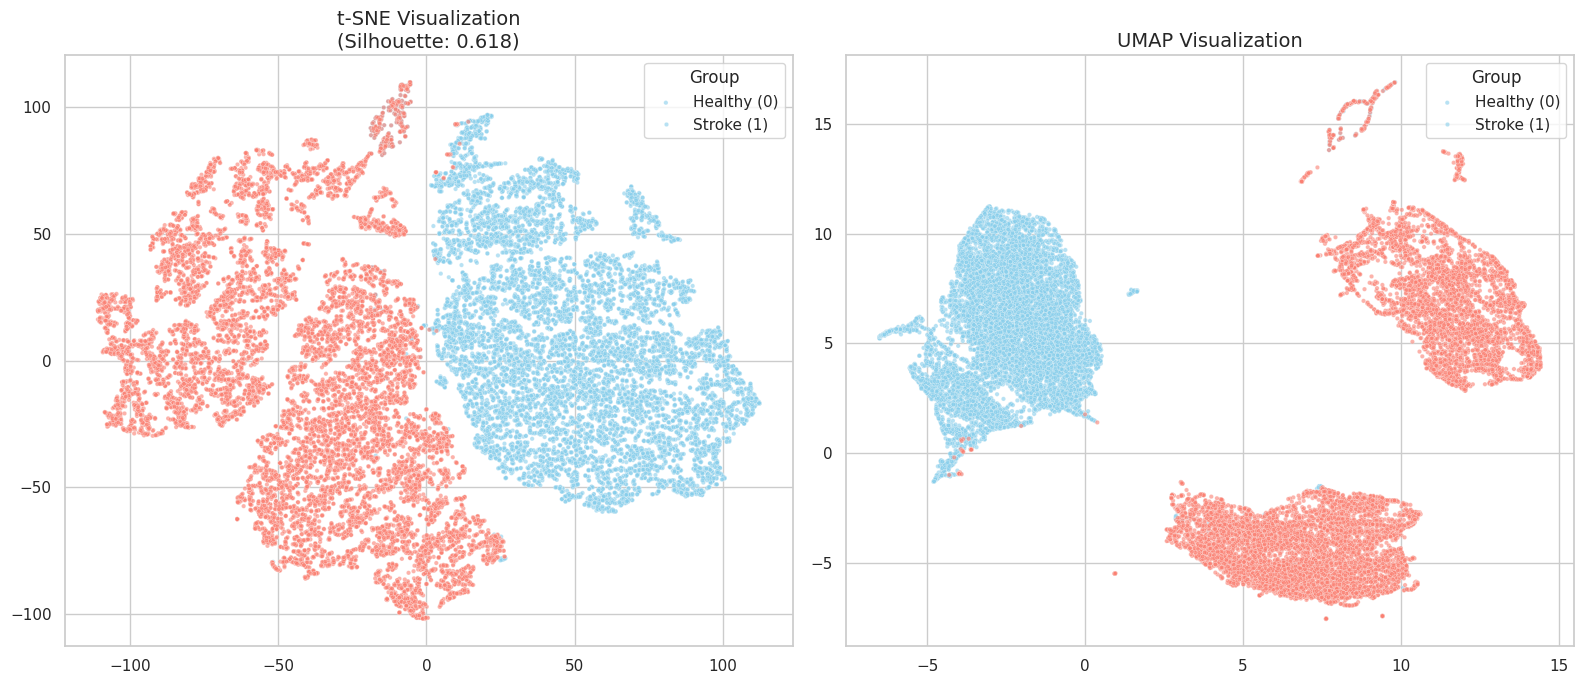

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
try:
    import umap
except ImportError:
    print("UMAP 라이브러리가 없습니다. 'pip install umap-learn'으로 설치 가능합니다. t-SNE만 진행합니다.")

# ==========================================
# [분석 1] 잠재 벡터(Latent Vector) 추출
# ==========================================
# 분류 레이어 이전의 'GlobalAveragePooling1D' 레이어 출력을 추출합니다.
latent_extractor = tf.keras.Model(inputs=model.input,
                                 outputs=model.get_layer('global_average_pooling1d').output)

print("Extracting latent vectors from all data...")
X_latent = latent_extractor.predict(X_all_raw, batch_size=256, verbose=0)
print(f"Latent Vector Shape: {X_latent.shape}") # (Samples, 128)

# ==========================================
# [분석 2] t-SNE 및 UMAP 실행
# ==========================================
print("Running dimensionality reduction (t-SNE)...")
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_latent)

# UMAP (설치된 경우에만 실행)
X_umap = None
if 'umap' in globals():
    print("Running dimensionality reduction (UMAP)...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_latent)

# ==========================================
# [분석 3] Silhouette Score 계산
# ==========================================
# 잠재 공간(Original Latent Space, 128D)에서의 군집화 성능 측정
score_latent = silhouette_score(X_latent, y_all)
print(f"\n[Result] Silhouette Score (128D Latent Space): {score_latent:.4f}")

# ==========================================
# [분석 4] 시각화 (Subplots)
# ==========================================
fig, axes = plt.subplots(1, 2 if X_umap is not None else 1, figsize=(16, 7))
if X_umap is None: axes = [axes]

# t-SNE Plot
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_all,
                palette={0: 'skyblue', 1: 'salmon'}, alpha=0.6, ax=axes[0], s=10)
axes[0].set_title(f't-SNE Visualization\n(Silhouette: {score_latent:.3f})', fontsize=14)
axes[0].legend(title='Group', labels=['Healthy (0)', 'Stroke (1)'])

# UMAP Plot (있을 경우)
if X_umap is not None:
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_all,
                    palette={0: 'skyblue', 1: 'salmon'}, alpha=0.6, ax=axes[1], s=10)
    axes[1].set_title('UMAP Visualization', fontsize=14)
    axes[1].legend(title='Group', labels=['Healthy (0)', 'Stroke (1)'])

plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import GroupKFold
from keras.callbacks import EarlyStopping
from sklearn.utils import class_weight

# 성능 지표를 저장할 딕셔너리 초기화
metrics_results = {
    'Fold': [],
    'Accuracy': [],
    'Balanced_Acc': [],
    'Precision': [],
    'Recall(Sensitivity)': [],
    'Specificity': [],
    'F1_Score': [],
    'AUC': []
}

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_all_raw, y_all, groups=meta_all['BaseID'])):
    print(f"\n>> Fold {fold+1} 통합 학습 시작...")

    X_train_f, X_test_f = X_all_raw[train_idx], X_all_raw[test_idx]
    y_train_f, y_test_f = y_all[train_idx], y_all[test_idx]

    tf.keras.backend.clear_session()
    model = build_reinforced_model()
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

    # 클래스 가중치 계산
    weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_f), y=y_train_f)
    cw_dict = {i: weights[i] for i in range(len(weights))}

    # 학습
    model.fit(X_train_f, y_train_f, epochs=50, batch_size=128,
              validation_data=(X_test_f, y_test_f), class_weight=cw_dict,
              callbacks=[EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)],
              verbose=0)

    # 평가 예측
    y_prob = model.predict(X_test_f, verbose=0)
    y_pred = (y_prob > 0.5).astype(int)

    # 혼동 행렬에서 TN, FP, FN, TP 추출
    tn, fp, fn, tp = confusion_matrix(y_test_f, y_pred).ravel()

    # 개별 지표 계산
    acc = accuracy_score(y_test_f, y_pred)
    b_acc = balanced_accuracy_score(y_test_f, y_pred)
    prec = precision_score(y_test_f, y_pred, zero_division=0)
    rec = recall_score(y_test_f, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_test_f, y_pred, zero_division=0)
    auc_val = roc_auc_score(y_test_f, y_prob)

    # 결과 저장
    metrics_results['Fold'].append(fold + 1)
    metrics_results['Accuracy'].append(acc)
    metrics_results['Balanced_Acc'].append(b_acc)
    metrics_results['Precision'].append(prec)
    metrics_results['Recall(Sensitivity)'].append(rec)
    metrics_results['Specificity'].append(spec)
    metrics_results['F1_Score'].append(f1)
    metrics_results['AUC'].append(auc_val)

    print(f"Fold {fold+1} 완료 - Recall: {rec:.4f}, Specificity: {spec:.4f}, AUC: {auc_val:.4f}")

# ==========================================
# 최종 성능표 데이터프레임 생성
# ==========================================
df_metrics = pd.DataFrame(metrics_results)
df_metrics.set_index('Fold', inplace=True)

# 평균 및 표준편차 행 추가
mean_row = df_metrics.mean()
std_row = df_metrics.std()

df_metrics.loc['Mean'] = mean_row
df_metrics.loc['Std'] = std_row

print("\n=== 5-Fold 교차 검증 종합 성능표 ===")
# 소수점 4자리까지 출력 포맷팅
display(df_metrics.round(4))


>> Fold 1 통합 학습 시작...
Fold 1 완료 - Recall: 0.8834, Specificity: 0.8071, AUC: 0.9248

>> Fold 2 통합 학습 시작...
Fold 2 완료 - Recall: 0.7162, Specificity: 0.7751, AUC: 0.8410

>> Fold 3 통합 학습 시작...
Fold 3 완료 - Recall: 0.9604, Specificity: 0.9709, AUC: 0.9950

>> Fold 4 통합 학습 시작...
Fold 4 완료 - Recall: 0.9634, Specificity: 0.9401, AUC: 0.9866

>> Fold 5 통합 학습 시작...
Fold 5 완료 - Recall: 0.9823, Specificity: 0.9783, AUC: 0.9970

=== 5-Fold 교차 검증 종합 성능표 ===


,Accuracy,Balanced_Acc,Precision,Recall(Sensitivity),Specificity,F1_Score,AUC
Fold,,,,,,,
1,0.8479,0.8452,0.8404,0.8834,0.8071,0.8614,0.9248
2,0.7427,0.7457,0.7957,0.7162,0.7751,0.7539,0.8410
3,0.9646,0.9657,0.9805,0.9604,0.9709,0.9704,0.9950
4,0.9531,0.9517,0.9533,0.9634,0.9401,0.9583,0.9866
5,0.9801,0.9803,0.9741,0.9823,0.9783,0.9782,0.9970
Mean,0.8977,0.8977,0.9088,0.9012,0.8943,0.9044,0.9489
Std,0.1010,0.1003,0.0849,0.1101,0.0959,0.0964,0.0672
